# Divervengence versus Convergence of -5, -17

Lets look at how the three parts interact to give use cycle lengths 3 and 11:

$$
\begin{aligned}
	V_{3k+j}(\sigma)
	&= \underbrace{((3k)+1)V_{0}(\sigma) - (3k)V_{-1}(\sigma)}_{\text{dominant expanding}}
	\\[6pt]
	&\quad + j \cdot \underbrace{(2V_{0}(\sigma) - V_{-1}(\sigma))}_{\text{period 2}}
	\\[6pt]
	&\quad - j \cdot \underbrace{V_{0}(\sigma)}_{\text{period 1}}, 
	\qquad j \in (1,2)
\end{aligned}
$$

For -5 and -17 we have:

- $-5$ : $k=-2$, $j=1$
- $-17$: $k=-6$, $j=1$

"00001000111" -- In order to keep from over-running -17, the cycle solution has to run along the bottom and then "pop up" at the end.

The longer a cycle gets, the harder it is going to be to get a matching terminating "popup".


In [307]:
import sys, io
import math
import numpy as np
import pandas as pd
from scipy.optimize import nnls
from fractions import Fraction
from sympy import factorint
from itertools import product, combinations
from typing import List, Optional, Tuple
import random
from scipy.sparse import coo_array
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import pandas as pd

from kenglish.mrlattice import (
    collatzPath,
    N_i, F_0, F_1, 
    mrTupToLaTex, mrTupFromPath, mrTupValue, mrTupRootedValue,
    generationRootedIntegersForwardWithMeta,
    generationIntegersForwardWithMeta, 
    countZeros, 
    generationAffineParamsFromPath,
    mrTupToLaTex
#    affineFunctionParamsFromPrefix,
)

# $V_{-5} = V_{-6} + V_{1} - V_{0}$

- $5 = 101b$: entropy = 0.9182958340544896
- "001"$\star \infty$ : entropy per symbol is 0.918295834

In [222]:
labels = ["", "0", "00", "001", "0010", "00100", "001001"]
for label in labels:
    T = mrTupFromPath(label)
    val_n5 = mrTupRootedValue(-5, T)
    val_n6 = mrTupRootedValue(-6, T)
    val_1 = mrTupRootedValue(1, T)
    val_0 = mrTupRootedValue(0, T)
    pad_label = (" "*(len(labels[-1])+1))[len(label):] + label
    print(f"{pad_label} {val_n5} = {val_n6} + {val_1} - {val_0}")

        (-5, 1) = (-6, 1) + (1, 1) - (0, 1)
      0 (-11, 3) = (-13, 3) + (1, 3) - (-1, 3)
     00 (-25, 9) = (-29, 9) + (-1, 9) - (-5, 9)
    001 (-5, 1) = (-53, 9) + (1, 3) - (-5, 9)
   0010 (-103, 27) = (-119, 27) + (-7, 27) - (-23, 27)
  00100 (-245, 81) = (-277, 81) + (-53, 81) - (-85, 81)
 001001 (-5, 1) = (-469, 81) + (-7, 27) - (-85, 81)


In [11]:
" "*(len(labels[-1])+1)

'       '

In [13]:
(-469 - 3*7 + 85) / 81

-5.0

### The $3^b$ effectively reduces the gap

What we are really having to overcome is $\frac{-5}{3}$ with a "$+2 - 1$ " which is possible with a cycle of 3

# $V_{-17} = V_{-18} + V_{1} - V_{0}$

- $17 = 10001b$ entropy = 0.9709505944546686
- "00001000111"$\star \infty$ : entropy per symbol is0.9456603046006401


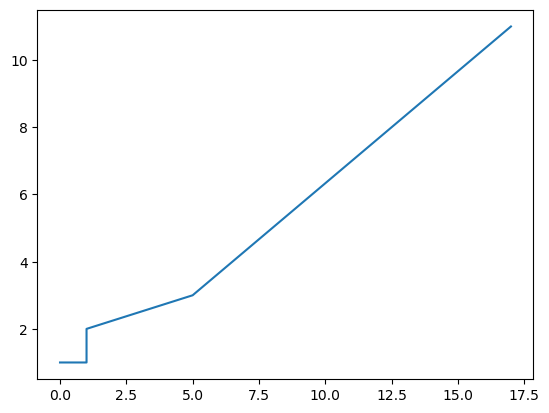

In [34]:
# Period Length versus $|r|$

X = [0, 1, 1, 5, 17]
Y = [1, 1, 2, 3, 11]
plt.plot(X, Y)
plt.show()

In [17]:
labels = [("00001000111"*2)[0:i] for i in range(23)]

In [19]:
for label in labels:
    T = mrTupFromPath(label)
    val_n17 = mrTupRootedValue(-17, T)
    val_n18 = mrTupRootedValue(-18, T)
    val_1 = mrTupRootedValue(1, T)
    val_0 = mrTupRootedValue(0, T)
    pad_label = (" "*(len(labels[-1])+1))[len(label):] + label
    print(f"{pad_label} {val_n17} = {val_n18} + {val_1} - {val_0}")

                        (-17, 1) = (-18, 1) + (1, 1) - (0, 1)
                      0 (-35, 3) = (-37, 3) + (1, 3) - (-1, 3)
                     00 (-73, 9) = (-77, 9) + (-1, 9) - (-5, 9)
                    000 (-155, 27) = (-163, 27) + (-11, 27) - (-19, 27)
                   0000 (-337, 81) = (-353, 81) + (-49, 81) - (-65, 81)
                  00001 (-203, 27) = (-641, 81) + (-11, 27) - (-65, 81)
                 000010 (-1315, 243) = (-1379, 243) + (-163, 243) - (-227, 243)
                0000100 (-2921, 729) = (-3049, 729) + (-617, 729) - (-745, 729)
               00001000 (-6715, 2187) = (-6971, 2187) + (-2107, 2187) - (-2363, 2187)
              000010001 (-3689, 729) = (-11579, 2187) + (-617, 729) - (-2363, 2187)
             0000100011 (-19771, 2187) = (-20795, 2187) + (-1339, 2187) - (-2363, 2187)
            00001000111 (-17, 1) = (-39227, 2187) + (-35, 243) - (-2363, 2187)
           000010001110 (-78769, 6561) = (-82865, 6561) + (-5041, 6561) - (-9137, 6561)
          

# $ V_{-53} = V_{-54} + V_{1} - V_{0}$

Because: $r = 3k+j$
- $-5$ : $k=-2$, $j=1$
- $-17$: $k=-6$, $j=1$

So:
- $k=-18$, $j=1$:  $\mapsto -53$

-53 has even period 34.


In [70]:
closest_label = ""
closest_val = 100000000

p = 22
N = 2**p
min_denom = 3**30
for idx in range(N):
    label = f"{idx:0{p}b}"
    label = "00000"+ label + "1111111"
    T = mrTupFromPath(label)
    val = mrTupRootedValue(-53, T)
    if val[1] < min_denom:
        min_denom = val[1]
    if val[1] == 1:
        if abs(closest_val - -53) > abs(val[0] - -53):
            closest_val = val[0]
            closest_label = label
#

In [71]:
min_denom

1

In [72]:
closest_val, closest_label

(-5140385, '0000011100101101111101111101111111')

# $ V_{-47} = V_{-48} + V_{1} - V_{0}$

# What is the closest value to -47 in generation 30?

root $-47$ would have an even period: $30$. ?

... I need more compute to really answer this one fully, but if we assume cycle label starts with 5 zeros and ends with 4 ones this is computable.


In [56]:
closest_label = ""
closest_val = 100000

p = 21
N = 2**p
min_denom = 3**30
for idx in range(N):
    label = f"{idx:0{p}b}"
    label = "00000"+ label + "1111"
    T = mrTupFromPath(label)
    val = mrTupRootedValue(-47, T)
    if val[1] < min_denom:
        min_denom = val[1]
    if val[1] == 1:
        if abs(closest_val - -47) > abs(val[0] - -47):
            closest_val = val[0]
            closest_label = label
#

In [59]:
closest_val, closest_label

(-95009, '000001101011111001001111011111')

In [58]:
min_denom

1

### ^^^ We do not get any integers in the range of labels were we expect a cycle to exist for $V_{-47}$

Had to keep expanding middle till I got an integer and -95009 is not very close to -47.

In [30]:
math.log(5, 3)

1.4649735207179269

In [31]:
math.log(17, 3)

2.5789019231625656

In [33]:
2**(-0.6036)

0.6581097039759024

In [60]:
a = 0
b = 0
for i in range(90):
    if 2**a <= 3**b:
        a += 1
    else:
        b += 1
    print((a, b, 1 - ((2**a)/(3**b))))

# Note that $b$ also winds up being period-length for a given $-a$ root lavttice value.

(1, 0, -1.0)
(1, 1, 0.33333333333333337)
(2, 1, -0.33333333333333326)
(2, 2, 0.5555555555555556)
(3, 2, 0.11111111111111116)
(4, 2, -0.7777777777777777)
(4, 3, 0.40740740740740744)
(5, 3, -0.18518518518518512)
(5, 4, 0.6049382716049383)
(6, 4, 0.2098765432098766)
(7, 4, -0.5802469135802468)
(7, 5, 0.4732510288065843)
(8, 5, -0.053497942386831365)
(8, 6, 0.6488340192043895)
(9, 6, 0.2976680384087792)
(10, 6, -0.4046639231824416)
(10, 7, 0.5317786922725194)
(11, 7, 0.0635573845450389)
(12, 7, -0.8728852309099222)
(12, 8, 0.3757049230300259)
(13, 8, -0.2485901539399482)
(13, 9, 0.5838032820200173)
(14, 9, 0.1676065640400346)
(15, 9, -0.6647868719199308)
(15, 10, 0.4450710426933564)
(16, 10, -0.1098579146132872)
(16, 11, 0.6300473617955709)
(17, 11, 0.26009472359114183)
(18, 11, -0.47981055281771634)
(18, 12, 0.5067298157274278)
(19, 12, 0.013459631454855736)
(20, 12, -0.9730807370902885)
(20, 13, 0.3423064209699038)
(21, 13, -0.31538715806019235)
(21, 14, 0.561537613979936)
(22, 14, 0.123

In [41]:
(-0.1098579146132872)*(3**10)

-6486.999999999995

In [40]:
(0.013459631454855736)*(3**12)

7152.999999999987

In [ ]:
[(0, 0, 0),
 (1, 1, 1/3),
 (3, 2, 1/9),
 (16, 10, -6487/(3**10)
 (19, 12, (7153/(3**12))),
 (84. 53, 0.0021),
 (485, 306, 0.001),
 (569, 359, 0.0011) 

# Largest integer for r < -17 at cycle-generation.

We see that the closest we get to the root is a value of -65 for root -32.  


In [79]:
a_over_b = math.log(2, 3)

In [82]:
round(a_over_b * -5)

-3

In [83]:
round(a_over_b * -17)

-11

In [77]:
math.log(17, 2)

4.08746284125034

In [100]:
a_over_b = math.log(2, 3)
def cycle_generation(r):
    a = abs(round(a_over_b * r))
    return a
#
D = {}
DD = {}
def collect_max(r, val, label):
    if r not in DD:
        DD[r] = (val[0]/val[1] , val, label)
    elif (val[0]/val[1]) > DD[r][0]:
        DD[r] = (val[0]/val[1], val, label)
    #
    if val[1] == 1:
        if r not in D:
            D[r] = (val[0], label)
        elif val[0] > D[r][0]:
            D[r] = (val[0], label)
#
for r in range (-17, -43, -2):
    if r % 3 == 0:
        # skip boring 3k lattices
        continue
    #
    if r in (-25, -37,  -55,  -82,  -41,  -61,  -91, -136, -68,  -34):
        # Skip -17 cycle related numbers
        continue
    #
    a = cycle_generation(r)
    print((r,a))
    N = 2**a
    for idx in range(N):
        label = f"{idx:0{a}b}"
        T = mrTupFromPath(label)
        val = mrTupRootedValue(r, T)
        collect_max(r, val, label)
#
    

(-17, 11)
(-19, 12)
(-20, 13)
(-22, 14)
(-23, 15)
(-26, 16)
(-28, 18)
(-29, 18)
(-31, 20)
(-32, 20)
(-35, 22)
(-38, 24)
(-40, 25)


In [101]:
D

{-17: (-17, '00001000111'),
 -19: (-322, '100000111111'),
 -20: (-679, '0100111010111'),
 -22: (-57, '00010101001011'),
 -23: (-351, '010100100111101'),
 -26: (-89, '0001001010011101'),
 -28: (-133, '001001010011101100'),
 -29: (-3487, '010100011101110111'),
 -31: (-1663, '01010100111001001111'),
 -32: (-65, '00000010011001101101'),
 -35: (-839, '0100101100011010100111'),
 -38: (-405, '001010010101010000011111'),
 -40: (-849, '0000101100100011011101011')}

In [102]:
DD

{-17: (-1.1849763191022145, (-209915, 177147), '00000000000'),
 -19: (-1.138732239326661, (-67241, 59049), '000000000000'),
 -20: (-1.0976263906372798, (-1749971, 1594323), '0000000000000'),
 -22: (-1.0719352352064169, (-1709011, 1594323), '00000000000000'),
 -23: (-1.0502404817314657, (-15069803, 14348907), '000000000000000'),
 -26: (-1.038060971008686, (-44685121, 43046721), '0000000000000000'),
 -28: (-1.0182692660841692, (-14611051, 14348907), '000000000000000000'),
 -29: (-1.0189459055687682, (-394760521, 387420489), '000000000000000000'),
 -31: (-1.0090218597946514, (-1172747227, 1162261467), '00000000000000000000'),
 -32: (-1.0093225884544732, (-3519290257, 3486784401), '00000000000000000000'),
 -35: (-1.0045443441928614,
  (-31523665945, 31381059609),
  '0000000000000000000000'),
 -38: (-1.0021979181063514,
  (-283050293473, 282429536481),
  '000000000000000000000000'),
 -40: (-1.0015444829936522,
  (-282865744097, 282429536481),
  '0000000000000000000000000')}

In [104]:
math.log(177147, 3)

11.0

In [107]:
factorint(209915 + 1)

{2: 2, 3: 2, 7: 3, 17: 1}

In [146]:
T = mrTupFromPath('00001000111')
print(mrTupToLaTex(T))
T = mrTupFromPath('00000000000')
print(mrTupToLaTex(T))


$ \frac{2^{11}}{3^{7}} - (   \frac{2^{0}}{3^{1}} + \frac{2^{1}}{3^{2}} + \frac{2^{2}}{3^{3}} + \frac{2^{3}}{3^{4}} + \frac{2^{5}}{3^{5}} + \frac{2^{6}}{3^{6}} + \frac{2^{7}}{3^{7}} ) $
$ \frac{2^{11}}{3^{11}} - (   \frac{2^{0}}{3^{1}} + \frac{2^{1}}{3^{2}} + \frac{2^{2}}{3^{3}} + \frac{2^{3}}{3^{4}} + \frac{2^{4}}{3^{5}} + \frac{2^{5}}{3^{6}} + \frac{2^{6}}{3^{7}} + \frac{2^{7}}{3^{8}} + \frac{2^{8}}{3^{9}} + \frac{2^{9}}{3^{10}} + \frac{2^{10}}{3^{11}} ) $


### $ \frac{2^{11}}{3^{7}} - (   \frac{2^{0}}{3^{1}} + \frac{2^{1}}{3^{2}} + \frac{2^{2}}{3^{3}} + \frac{2^{3}}{3^{4}} + \frac{2^{5}}{3^{5}} + \frac{2^{6}}{3^{6}} + \frac{2^{7}}{3^{7}} ) $

### $ \frac{2^{11}}{3^{11}} - (   \frac{2^{0}}{3^{1}} + \frac{2^{1}}{3^{2}} + \frac{2^{2}}{3^{3}} + \frac{2^{3}}{3^{4}} + \frac{2^{4}}{3^{5}} + \frac{2^{5}}{3^{6}} + \frac{2^{6}}{3^{7}} + \frac{2^{7}}{3^{8}} + \frac{2^{8}}{3^{9}} + \frac{2^{9}}{3^{10}} + \frac{2^{10}}{3^{11}} ) $

In [178]:
(729*1) + (243*2) + (81*4 + 27*8), 9*32 + 3*64 + 1*128, (1755 + 608), 2363/17

(1755, 608, 2363, 139.0)

In [205]:
81 * 1755,  729*16, 27*608 , 9*256 + 3*512 + 1*1024, (142155 + 11664 + 16416 + 4864)

(142155, 11664, 16416, 4864, 175099)

In [195]:
59049 + 39366 + 26244 + 17496,  11664, 7776 + 5184 + 3456,  2304 + 1536 + 1024

(142155, 11664, 16416, 4864)

In [200]:
factorint(1824)

{2: 5, 3: 1, 19: 1}

In [198]:
3**6

729

In [211]:
(729*1 + 243*2 + 81*4 + 27*8) % 17, (9*32 + 3*64 + 1*128) % 17

(4, 13)

In [214]:
(81*( 729*1 + 243*2 + 81*4 + 27*8 )) % 17, (27* ( 9*32 + 3*64 + 1*128 )) % 17

(1, 11)

In [216]:
(729*16) % 17, (9*256 + 3*512 + 1*1024) % 17

(2, 2)

In [219]:
1 + 11 + 2 + 2  # 1, 11 are desendents of 4, 13.  2, 2 are from the picked up sections from the full expansion for 000...

16

... which again is why we need to add 1

In [208]:
(209915 + 1)/ 17

12348.0

In [206]:
-17 * (2**11) - 175099

-209915

In [192]:
f = Fraction(-191435, 3**11)
f.numerator, f.denominator

(-191435, 177147)

## 3**6

In [159]:
accum = 0
cc = [0, 1, 2, 3, 5, 6, 7]
n = len(cc)
for i in range(n):
    accum += (3**((n-1)-i))*(2**(cc[i]))
accum

2363

In [155]:
-17*(2**11) - 2363

-37179

In [156]:
factorint(37179)

{3: 7, 17: 1}

In [194]:
accum = 0
cc = list(range(11))
n = len(cc)
for i in range(n):
    x = (3**((n-1)-i))*(2**(cc[i]))
    print(x)
    accum += x
accum

59049
39366
26244
17496
11664
7776
5184
3456
2304
1536
1024


175099

In [161]:
-17 * (2**11) - (175099)

-209915

In [163]:
factorint(209915+1)

{2: 2, 3: 2, 7: 3, 17: 1}

### ^^^ 17 being a factor of 00000000000 (numerator + 1) means something ?

In [165]:
T = mrTupFromPath('001')
print(mrTupToLaTex(T))
T = mrTupFromPath('000')
print(mrTupToLaTex(T))


$ \frac{2^{3}}{3^{2}} - (   \frac{2^{0}}{3^{1}} + \frac{2^{1}}{3^{2}} ) $
$ \frac{2^{3}}{3^{3}} - (   \frac{2^{0}}{3^{1}} + \frac{2^{1}}{3^{2}} + \frac{2^{2}}{3^{3}} ) $


### $ \frac{2^{3}}{3^{2}} - (   \frac{2^{0}}{3^{1}} + \frac{2^{1}}{3^{2}} ) $

### $ \frac{2^{3}}{3^{3}} - (   \frac{2^{0}}{3^{1}} + \frac{2^{1}}{3^{2}} + \frac{2^{2}}{3^{3}} ) $

In [167]:
accum = 0
cc = [0, 1]
n = len(cc)
for i in range(n):
    accum += (3**((n-1)-i))*(2**(cc[i]))
accum

5

In [169]:
-5*(2**3) - 5

-45

In [170]:
-45//9

-5

In [168]:
accum = 0
cc = list(range(3))
n = len(cc)
for i in range(n):
    accum += (3**((n-1)-i))*(2**(cc[i]))
accum

19

In [171]:
-5*(2**3) - 19

-59

In [172]:
-59 / 27

-2.185185185185185

In [130]:
T = mrTupFromPath("000")
val = mrTupRootedValue(-5, T)
val

(-59, 27)

In [131]:
factorint(59 + 1)

{2: 2, 3: 1, 5: 1}

### ^^^ 5 is a factor for cycle 3 case of 000 ...

In [125]:
11 * 27

297

In [129]:
accum = 0
for c in range(1, 4):
    d = 4 - c
    accum += ((2**c)*(3**d))
accum

114

In [108]:
(2**2)*(3**2)*(7**3)*17

209916

In [109]:
math.log(59049, 3)

9.999999999999998

In [113]:
factorint(67241*9 + 1)

{2: 1, 5: 1, 73: 1, 829: 1}

In [120]:
factorint(1749971+ 1)

{2: 2, 3: 1, 7: 1, 83: 1, 251: 1}

In [232]:
# Value of "0000..." label as we hit cycle length for decreasing negative r values
# These do not grow.  Rather asymptotically approach -1
for j in range(2, 20):
    r = - round(j/a_over_b)
    accum = 0
    cc = list(range(j))
    n = len(cc)
    for i in range(n):
        x = (3**((n-1)-i))*(2**(cc[i]))
        accum += x
    numer = (r * (2**j)) - accum
    denom = 3**j
    print((r, j, numer/denom))

(-3, 2, -1.8888888888888888)
(-5, 3, -2.185185185185185)
(-6, 4, -1.9876543209876543)
(-8, 5, -1.9218106995884774)
(-10, 6, -1.7901234567901234)
(-11, 7, -1.5852766346593508)
(-13, 8, -1.4682213077274806)
(-14, 9, -1.338159833358736)
(-16, 10, -1.2601229487374892)
(-17, 11, -1.1849763191022145)
(-19, 12, -1.138732239326661)
(-21, 13, -1.1027646217234526)
(-22, 14, -1.0719352352064169)
(-24, 15, -1.052524139991987)
(-25, 16, -1.0365385321683387)
(-27, 17, -1.0263889398993558)
(-29, 18, -1.0189459055687682)
(-30, 19, -1.0130816967022447)


# Cycle Influence

What fraction of the numerator of the result is affected by the cycle portion

Start with the "000..." labels where we expect the biggest influence



In [240]:
# Value of "0000..." label as we hit cycle length for decreasing negative r values
# These do not grow.  Rather asymptotically approach -1
for j in range(3, 20):
    r = - round(j/a_over_b)
    accum = 0
    cc = list(range(j))
    n = len(cc)
    for i in range(n):
        x = (3**((n-1)-i))*(2**(cc[i]))
        accum += x

    r_exp = r - 1

    print(accum)
    print(r_exp * (2**j))
    numer_exp = (r_exp * (2**j)) - accum
    print((-1 *(2**j)))
    numer_cyc = (2* ((-1 *(2**j)) - accum)) + accum

    print((r, j, numer_cyc/numer_exp, numer_cyc, numer_exp))

19
-48
-8
(-5, 3, 0.5223880597014925, -35, -67)
65
-112
-16
(-6, 4, 0.5480225988700564, -97, -177)
211
-288
-32
(-8, 5, 0.5511022044088176, -275, -499)
665
-704
-64
(-10, 6, 0.579254930606282, -793, -1369)
2059
-1536
-128
(-11, 7, 0.6439499304589708, -2315, -3595)
6305
-3584
-256
(-13, 8, 0.6893518050358984, -6817, -9889)
19171
-7680
-512
(-14, 9, 0.7521135153253138, -20195, -26851)
58025
-17408
-1024
(-16, 10, 0.796375591584585, -60073, -75433)
175099
-36864
-2048
(-17, 11, 0.8454069814071323, -179195, -211963)
527345
-81920
-4096
(-19, 12, 0.8789886174324801, -535537, -609265)
1586131
-180224
-8192
(-21, 13, 0.9072440138024349, -1602515, -1766355)
4766585
-376832
-16384
(-22, 14, 0.933105948827404, -4799353, -5143417)
14316139
-819200
-32768
(-24, 15, 0.950205013577826, -14381675, -15135339)
42981185
-1703936
-65536
(-25, 16, 0.9648011694989033, -43112257, -44685121)
129009091
-3670016
-131072
(-27, 17, 0.9743149311368217, -129271235, -132679107)
387158345
-7864320
-262144
(-29, 18, 

# Wiggle the -17 suffix bit

The ability to get a number greater than the root is critical.  When we cannot do that we have lost the ability to get back to the root.

In [246]:
# Far Left of the cycle
T = mrTupFromPath('10000000111')
val = mrTupRootedValue(-17, T)
val, val[0]/val[1]

((-1442, 81), -17.80246913580247)

In [244]:
# Left of the cycle
T = mrTupFromPath('00010000111')
val = mrTupRootedValue(-17, T)
val, val[0]/val[1]

((-1385, 81), -17.098765432098766)

In [242]:
# The cylce
T = mrTupFromPath('00001000111')
val = mrTupRootedValue(-17, T)
val

(-17, 1)

In [245]:
# Right of the cycle
T = mrTupFromPath('00000100111')
val = mrTupRootedValue(-17, T)
val, val[0]/val[1]

((-4115, 243), -16.93415637860082)

In [247]:
# Far right of the cycle
T = mrTupFromPath('00000001111')
val = mrTupRootedValue(-17, T)
val, val[0]/val[1]

((-36875, 2187), -16.860996799268403)

# Negative cycles > -11 possible based on label limits

For almost any root $r$, $r \lt -17$ we can generate a rational that is greater than the root value by generating labels "0...01...1" of the cycle length and appropriate zero:one ratio for the given root.

But the label range where this can happen is extremely limited.  

In [309]:
# 3k+1 cases 
#
# Except for roots -20, -23 we always have positive headroom
#
for r in range(-17, -70, -3):
    if r % 3 == 0:
        # skip boring 3k cases
        continue
    len_cycle = round(round(abs(r) * a_over_b))
    zero_count = round(len_cycle * a_over_b)
    one_count = len_cycle - zero_count
    print((r, zero_count, one_count))
    label = ("0" * zero_count) + ("1" * one_count)
    T = mrTupFromPath(label)
    val = mrTupRootedValue(r, T)
    print((val, r - val[0]/val[1], (r - val[0]/val[1])/r ))
#

(-17, 7, 4)
((-36875, 2187), -0.13900320073159733, 0.008176658866564549)
(-20, 8, 5)
((-18905, 729), 5.932784636488339, -0.296639231824417)
(-23, 9, 6)
((-772835, 19683), 16.26408575928466, -0.7071341634471592)
(-26, 10, 6)
((-1761961, 59049), 3.838964250029637, -0.14765247115498603)
(-29, 11, 7)
((-2592425, 59049), 14.902945011769887, -0.513894655578272)
(-32, 13, 7)
((-3904507, 177147), -9.958943702123097, 0.3112169906913468)
(-35, 14, 8)
((-151567225, 4782969), -3.311058465986296, 0.09460167045675132)
(-38, 15, 9)
((-217283449, 4782969), 7.428571458439308, -0.1954887225905081)
(-41, 16, 10)
((-2794444609, 43046721), 23.916549834306778, -0.58333048376358)
(-44, 18, 10)
((-12198318409, 387420489), -12.514008021398165, 0.28440927321359466)
(-47, 19, 11)
((-1912133441, 43046721), -2.5800442732908735, 0.054894559006188795)
(-50, 20, 12)
((-218234100625, 3486784401), 12.588928802827922, -0.25177857605655846)
(-53, 21, 12)
((-465724789427, 10460353203), -8.477144950188546, 0.15994613113563

In [310]:
# 3k+2 cases 
#
# Always have positive headroom

for r in range(-19, -70, -3):
    if r % 3 == 0:
        # skip boring 3k cases
        continue
    len_cycle = round(round(abs(r) * a_over_b))
    zero_count = round(len_cycle * a_over_b)
    one_count = len_cycle - zero_count
    print((r, zero_count, one_count))
    label = ("0" * zero_count) + ("1" * one_count)
    T = mrTupFromPath(label)
    val = mrTupRootedValue(-r, T)
    print((val, r - val[0]/val[1], (r - val[0]/val[1])/r ))
#

(-19, 8, 4)
((71519, 6561), -29.90062490474013, 1.5737171002494805)
(-22, 9, 5)
((113759, 6561), -39.33866788599299, 1.788121267545136)
(-25, 10, 6)
((1580375, 59049), -51.76378939524801, 2.0705515758099207)
(-28, 11, 7)
((2388311, 59049), -68.44625649883994, 2.444509160672855)
(-31, 13, 7)
((381725, 19683), -50.393639181019154, 1.6256012639038437)
(-34, 13, 8)
((69717037, 1594323), -77.72830160513271, 2.286126517798021)
(-37, 15, 8)
((296062357, 14348907), -57.63309470191702, 1.5576512081599194)
(-40, 16, 9)
((433065365, 14348907), -70.18106988915602, 1.7545267472289006)
(-43, 17, 10)
((5642353213, 129140163), -86.6916996380127, 2.0160860380933183)
(-46, 18, 11)
((8102967869, 129140163), -108.74552920457441, 2.3640332435777047)
(-49, 20, 11)
((33913654309, 1162261467), -78.17902319908882, 1.5954902693691595)
(-52, 21, 12)
((436218342733, 10460353203), -93.70206629427139, 1.801962813351373)
(-55, 22, 13)
((619469581645, 10460353203), -114.22071364352571, 2.076740248064104)
(-58, 23, 14

# Does divergence increase when we double the "cycle-probe" pattern?

Yes, the divergence grows, but unevenly and it keeps changing sign.


In [311]:
# 3k+1 cases 
#
for r in range(-17, -150, -3):
    if r % 3 == 0:
        # skip boring 3k cases
        continue
    if r in (-25, -37,  -55,  -82,  -41,  -61,  -91, -136, -68,  -34):
        # Skip -17 cycle related numbers
        continue
    #
    len_cycle = round(round(abs(r) * a_over_b))
    zero_count = round(len_cycle * a_over_b)
    one_count = len_cycle - zero_count
    print((r, zero_count, one_count))
    label = ("0" * zero_count) + ("1" * one_count)
    T = mrTupFromPath(label)
    val = mrTupRootedValue(r, T)
    label_ = label+label+label
    T_ = mrTupFromPath(label_)
    val_ = mrTupRootedValue(r, T_)
    label__ = label_+label_+label_
    T__ = mrTupFromPath(label__)
    val__ = mrTupRootedValue(r, T__)

    divergence = (val[0]/val[1]) - (val_[0]/val_[1])
    divergence_ = (val_[0]/val_[1]) - (val__[0]/val__[1])
    
    print((r, divergence, divergence_))
#

(-17, 7, 4)
(-17, -0.25206387096410765, -0.584857345886654)
(-20, 8, 5)
(-20, 16.65669348686014, 129.5614704380945)
(-23, 9, 6)
(-23, 72.1523994485143, 2290.2358877339493)
(-26, 10, 6)
(-26, 8.989481863977876, 41.51393378084122)
(-29, 11, 7)
(-29, 54.68858955514716, 956.3055614832213)
(-32, 13, 7)
(-32, -10.857782418925808, -7.6070242975866105)
(-35, 14, 8)
(-35, -5.449743402480067, -9.89185602699187)
(-38, 15, 9)
(-38, 18.841374808982195, 109.113714181865)
(-44, 18, 10)
(-44, -14.67842970225314, -12.054028708689987)
(-47, 19, 11)
(-47, -4.585553739773772, -10.104701231600796)
(-50, 20, 12)
(-50, 34.60794555799579, 253.07242653083614)
(-53, 21, 12)
(-53, -12.677928813504295, -18.20254824897375)
(-56, 22, 13)
(-56, 14.485988437059802, 63.14616837928743)
(-59, 23, 14)
(-59, 101.03278124787674, 1652.3707542681648)
(-62, 25, 14)
(-62, -22.222511487903393, -14.952362733614295)
(-65, 26, 15)
(-65, -12.532687240726737, -21.654374955430455)
(-71, 28, 17)
(-71, 153.00457940255626, 3243.05296172

# Cycle Gap factors

We see Zsigmondy's theorem in action with the growing prime numbers in the gaps making integer cycle solutions impossible

### Convergence improving pairs $\frac{2^a}{3^b} \mapsto 1$

In [293]:
pairs = [(2, 1), (3, 2), (8, 5), (19, 12), (65, 41), (84, 53) ] # too big :(485, 306)
for tup in pairs:
    a, b = tup
    gap = (2**(a+b) - 3**b)
    if gap > 0:
        print(f"impossible cycle for pair {tup}: {zero_count}:{one_count}")
    print((tup, gap, factorint(-gap)))

impossible cycle for pair (2, 1): 13:8
((2, 1), 5, {5: 1, -1: 1})
impossible cycle for pair (3, 2): 13:8
((3, 2), 23, {23: 1, -1: 1})
impossible cycle for pair (8, 5): 13:8
((8, 5), 7949, {7949: 1, -1: 1})
impossible cycle for pair (19, 12): 13:8
((19, 12), 2146952207, {1601: 1, 1341007: 1, -1: 1})
impossible cycle for pair (65, 41): 13:8
((65, 41), 81129638414570208699411834357661, {647687: 1, 125260563226636027432095803: 1, -1: 1})
impossible cycle for pair (84, 53): 13:8
((84, 53), 174224571863520473910002131325045427468749, {167: 1, 248851: 1, mpz(205626481): 1, mpz(13283801977): 1, 1534801123277281: 1, -1: 1})


In [285]:
def collatzChain(collatzNumber):
    chain = [collatzNumber]
    while not (collatzNumber in [1, -1, -5, -17]):
        if (collatzNumber & 1) == 0:
            collatzNumber = collatzNumber // 2
        else:
            collatzNumber = (3 * collatzNumber + 1) // 2
        chain.append(collatzNumber)
    return np.array(chain)
#


In [286]:
# -5 case
for r in [-5, -7, -10]:
    len_cycle = round(round(abs(r) * a_over_b))
    zero_count = round(len_cycle * a_over_b)
    one_count = len_cycle - zero_count
    #print((r, zero_count, one_count))
    gap = (2**len_cycle - 3**zero_count)
    if gap > 0:
        print(f"impossible cycle for {r}: {zero_count}:{one_count}")
    else:
        print((r, gap, factorint(-gap)))
    

(-5, -1, {})
(-7, -11, {11: 1})
(-10, -17, {17: 1})


In [287]:
# The -11 gap is covered by the -1 lattice
collatzChain(-11)

array([-11, -16,  -8,  -4,  -2,  -1])

In [288]:
# -17 case
for r in [-17, -25, -37, -55, -82, -41, -61, -91, -136, -68, -34]:
    len_cycle = round(round(abs(r) * a_over_b))
    zero_count = round(len_cycle * a_over_b)
    one_count = len_cycle - zero_count
    #print((r, zero_count, one_count))
    gap = (2**len_cycle - 3**zero_count)
    if gap > 0:
        print(f"impossible cycle for {r}: {zero_count}:{one_count}")
    else:
        print((r, gap, factorint(-gap)))
    

(-17, -139, {139: 1})
impossible cycle for -25: 10:6
(-37, -5960299, {431: 1, 13829: 1})
impossible cycle for -55: 22:13
(-82, -1055460939185027, {47: 1, 8627: 1, 2603061983: 1})
impossible cycle for -41: 16:10
(-61, -7551629537, {23: 1, 131: 1, 311: 1, 8059: 1})
(-91, -5979447221143249, {7: 1, 23: 1, 311: 1, 119419368919: 1})
impossible cycle for -136: 54:32
impossible cycle for -68: 27:16
impossible cycle for -34: 13:8


### ^^^ If we didn't know these r values were part of the $-17$ cycle we would declare these invalid cycle intitators.

In [300]:
def minPrimeGapCycleLength(prime):
    len_cycle = math.floor(math.log(prime, 3)/a_over_b)
    return len_cycle
#

# And we see that -17 cycle length of 11 is greater than 7.
minPrimeGapCycleLength(139)

7

In [306]:
# 3k+1 cases 
#
for r in range(-4, -200, -1):
    if r % 3 == 0:
        # skip boring 3k cases
        continue
    if r in (-25, -37,  -55,  -82,  -41,  -61,  -91, -136, -68,  -34):
        # Skip -17 cycle related numbers
        continue
    #
    len_cycle = round(round(abs(r) * a_over_b))
    zero_count = round(len_cycle * a_over_b)
    one_count = len_cycle - zero_count
    #print((r, zero_count, one_count))
    gap = (2**len_cycle - 3**zero_count)
    T = mrTupFromPath(("0"*zero_count) + ("1"*one_count))
    val = mrTupRootedValue(r, T)
    f = val[0]/val[1]
    if gap > 0:
        print(f"impossible cycle for {r}: {zero_count}:{one_count}")
    else:
        factor_dict = factorint(-gap)
        if len(factor_dict) == 0:
            factor_dict = {1:1}
        min_prime_cycle = minPrimeGapCycleLength(math.prod((factor_dict.keys())))
        print((r, len_cycle, gap, min_prime_cycle, f"{zero_count}:{one_count}", factor_dict))
#

(-4, 3, -1, 0, '2:1', {1: 1})
(-5, 3, -1, 0, '2:1', {1: 1})
(-7, 4, -11, 3, '3:1', {11: 1})
impossible cycle for -8: 3:2
(-10, 6, -17, 4, '4:2', {17: 1})
impossible cycle for -11: 4:3
impossible cycle for -13: 5:3
(-14, 9, -217, 7, '6:3', {7: 1, 31: 1})
impossible cycle for -16: 6:4
(-17, 11, -139, 7, '7:4', {139: 1})
(-19, 12, -2465, 11, '8:4', {5: 1, 17: 1, 29: 1})
impossible cycle for -20: 8:5
(-22, 14, -3299, 11, '9:5', {3299: 1})
impossible cycle for -23: 9:6
impossible cycle for -26: 10:6
impossible cycle for -28: 11:7
impossible cycle for -29: 11:7
(-31, 20, -545747, 19, '13:7', {545747: 1})
(-32, 20, -545747, 19, '13:7', {545747: 1})
(-35, 22, -588665, 15, '14:8', {5: 1, 7: 1, 11: 2, 139: 1})
impossible cycle for -38: 15:9
(-40, 25, -9492289, 23, '16:9', {9492289: 1})
impossible cycle for -43: 17:10
(-44, 28, -118985033, 26, '18:10', {3299: 1, 36067: 1})
impossible cycle for -46: 18:11
(-47, 30, -88519643, 26, '19:11', {193: 1, 458651: 1})
(-49, 31, -1339300753, 30, '20:11', {7

# Unfortunately, Zigmoidy always gives a weaker constraint than just the a:b ratio.